<a href="https://colab.research.google.com/github/tjpel/AIHC5020/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6


In [9]:
import io

import matplotlib.pyplot as plt
import pandas as pd
from google.auth.credentials import AnonymousCredentials
from google.cloud import bigquery, storage

---

## Problem 1: Loading Data from Google Cloud Storage

In [10]:
COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income_bracket'
]

storage_client = storage.Client(credentials=AnonymousCredentials())
bucket = storage_client.bucket('cloud-samples-data')

In [11]:
blobs = list(storage_client.list_blobs(bucket, prefix='ml-engine'))
print(f'{len(blobs)} blobs found under the ml-engine prefix.')
print()

print('Matches for "adult.data.csv":')
for blob in blobs:
    if blob.name.endswith('adult.data.csv'):
        print(' ', blob.name)

14423 blobs found under the ml-engine prefix.

Matches for "adult.data.csv":
  ml-engine/census/data/adult.data.csv


In [12]:
def load_csv_blob(blob_name, bucket, column_names=[]):
    """Load a CSV blob from a GCS bucket into a pandas DataFrame.

    Args:
        blob_name: Full path of the blob within the bucket.
        bucket: A google.cloud.storage Bucket object.
        column_names: Optional list of column names. If empty, columns are
            left unnamed (integer positions).

    Returns:
        A pandas DataFrame with the contents of the CSV.
    """
    blob = bucket.blob(blob_name)
    data = io.BytesIO(blob.download_as_bytes())

    if column_names:
        return pd.read_csv(data, header=None, names=column_names)
    return pd.read_csv(data, header=None)

In [13]:
ADULT_BLOB_NAME = 'ml-engine/census/data/adult.data.csv'

census_df = load_csv_blob(ADULT_BLOB_NAME, bucket, COLUMN_NAMES)

print('Shape:', census_df.shape)
census_df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---

## Problem 2: Querying from BigQuery

In [14]:
from google.colab import auth

auth.authenticate_user()
print('Authenticated.')

Authenticated.


In [15]:
PROJECT_ID = 'speedy-equator-383401'

client = bigquery.Client(project=PROJECT_ID)
print('BigQuery client ready for project:', client.project)

BigQuery client ready for project: speedy-equator-383401


In [16]:
query = """
    SELECT
        date,
        new_confirmed,
        new_deceased
    FROM
        `bigquery-public-data.covid19_open_data.covid19_open_data`
    WHERE
        country_name = 'Mexico'
        AND EXTRACT(YEAR FROM date) = 2021
    ORDER BY
        date ASC
"""

query_job = client.query(query)
mexico_covid_df = query_job.to_dataframe()

In [17]:
print('Number of rows:', len(mexico_covid_df))
mexico_covid_df.head()

Number of rows: 911770


,date,new_confirmed,new_deceased
0,2021-01-01,<NA>,<NA>
1,2021-01-01,<NA>,<NA>
2,2021-01-01,<NA>,<NA>
3,2021-01-01,<NA>,<NA>
4,2021-01-01,<NA>,<NA>


---

## Problem 3: Aggregating and Visualizing the Data

In [18]:
mexico_covid_df['month'] = mexico_covid_df['date'].apply(lambda dt: dt.month)

monthly_totals = (
    mexico_covid_df
    .groupby('month')[['new_confirmed', 'new_deceased']]
    .sum()
)

monthly_totals

,new_confirmed,new_deceased
month,,
1,424394,39156
2,195234,23558
3,143254,13099
4,93647,7606
5,65871,4004
6,107135,3152
7,381611,8735
8,523222,22656
9,273774,16481


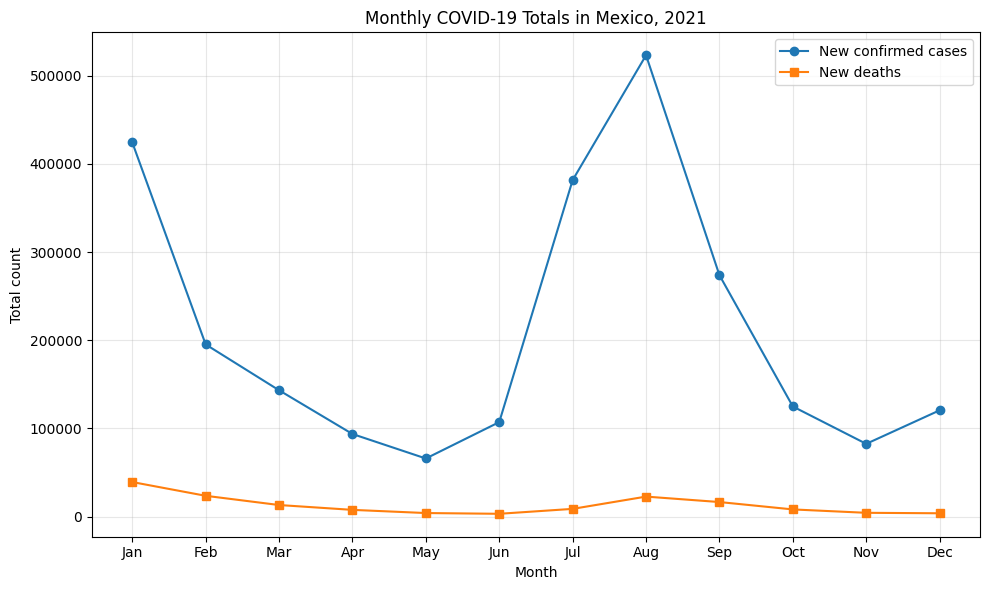

In [19]:
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(monthly_totals.index, monthly_totals['new_confirmed'],
        marker='o', label='New confirmed cases')
ax.plot(monthly_totals.index, monthly_totals['new_deceased'],
        marker='s', label='New deaths')

ax.set_title('Monthly COVID-19 Totals in Mexico, 2021')
ax.set_xlabel('Month')
ax.set_ylabel('Total count')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()